# Rendements journaliers sur 12 mois — IPO 2019-2024

Ce notebook produit :
1. **Trajectoire base 100 agrégée** (médiane + moyenne par cohorte) sur 252 jours de trading — extension sur 12 mois de la section 6.1 existante.
2. **Graphiques individuels** de chaque ticker (index base 100 depuis l'offer price), arrangés en grille, colorés par cohorte.
3. **Distribution des rendements journaliers** : boxplot et violin par trimestre pour les deux cohortes.

Les **split-suspects** (`ratio_closeJ0_offer > 5` ou `< 0.2`) sont exclus, comme dans H3/H4.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

COLORS  = {'2019-2021': '#2C7BB6', '2022-2024': '#D7191C'}
IMG_DIR = Path('images_12m')
IMG_DIR.mkdir(exist_ok=True)

# Chemins (mêmes que le notebook principal)
PATH_DATASET   = '../data/dataset.xlsx'
PATH_DAILY_RET = '../data/daily_returns_cache.csv'
PATH_OFFER_PRICE = '../data/offer_prices_from_sec.xlsx'


In [ ]:
# ── Chargement des données ──────────────────────────────────────────────────
ds = pd.read_excel(PATH_DATASET)
dr = pd.read_csv(PATH_DAILY_RET)

# Construction de df_final (filtre identique au notebook principal)
df_final = ds.copy()
df_final['year']        = pd.to_numeric(df_final['year'], errors='coerce')
df_final = df_final[df_final['year'].between(2019, 2024)].copy()
df_final['cohort']      = np.where(df_final['year'].between(2019, 2021), '2019-2021', '2022-2024')
df_final['Size_Million']= pd.to_numeric(df_final['Size_Million'], errors='coerce')
df_final['OfferPrice']  = pd.to_numeric(df_final['OfferPrice'],   errors='coerce')
df_final = df_final[(df_final['Size_Million'].isna()) | (df_final['Size_Million'] >= 50)]
df_final = df_final[(df_final['OfferPrice'].isna())   | (df_final['OfferPrice']   > 5)]
df_final = df_final.reset_index(drop=True)

# Prix journaliers — filtré sur les tickers de df_final
pj = dr[dr['ticker'].isin(df_final['ticker'])].copy()
pj = pj.drop(columns=[c for c in ['cohort','year'] if c in pj.columns])
pj = pj.merge(df_final[['ticker','cohort','OfferPrice']], on='ticker', how='left')

# Close J0 pour détecter les split-suspects
close_j0 = (pj.sort_values(['ticker','trading_day'])
              .groupby('ticker')['close'].first()
              .rename('close_J0'))
df_final = df_final.merge(close_j0, on='ticker', how='left')
df_final['ratio_closeJ0_offer'] = df_final['close_J0'] / df_final['OfferPrice']
df_final['split_suspect']       = (
    (df_final['ratio_closeJ0_offer'] > 5) | (df_final['ratio_closeJ0_offer'] < 0.2)
)

print(f"df_final : {len(df_final)} IPO — split-suspects : {df_final['split_suspect'].sum()}")
print(df_final['cohort'].value_counts().sort_index())


df_final : 407 IPO — split-suspects : 40
cohort
2019-2021    271
2022-2024    136
Name: count, dtype: int64


## 1. Trajectoire base 100 agrégée sur 12 mois

Pour chaque ticker non-suspect, on calcule `indice_100 = 100 × close / OfferPrice` pour chaque jour de trading de 0 à 252.
On agrège ensuite par cohorte (médiane + moyenne).


In [ ]:
# Tickers valides (non split-suspects, avec OfferPrice connue)
tickers_ok = df_final.loc[
    ~df_final['split_suspect'] & df_final['OfferPrice'].notna(),
    ['ticker','cohort','OfferPrice']
].copy()

# Merge avec prix journaliers, fenêtre 0–252
ref  = tickers_ok.copy()
traj = pj.merge(ref, on=['ticker','cohort','OfferPrice'], how='inner')
traj = traj[traj['trading_day'].between(1, 252)].copy()
traj['indice_100'] = 100.0 * traj['close'] / traj['OfferPrice']

# Ajouter le jour 0 (base = 100)
t0 = ref.copy()
t0['trading_day'] = 0
t0['indice_100']  = 100.0
traj = pd.concat([t0[['ticker','cohort','trading_day','indice_100']],
                  traj[['ticker','cohort','trading_day','indice_100']]],
                 ignore_index=True)

# Agréger par cohorte + trading_day
agg = (traj.groupby(['cohort','trading_day'])['indice_100']
           .agg(median='median', mean='mean', q25=lambda x: x.quantile(0.25),
                q75=lambda x: x.quantile(0.75), count='count')
           .reset_index())

print(f"Tickers inclus : {traj['ticker'].nunique()}")
print(agg[agg['trading_day'] == 252][['cohort','median','mean','count']])


Tickers inclus : 367
        cohort      median        mean  count
252  2019-2021   95.502345  130.722728    234
505  2022-2024  105.240002  114.237692    131


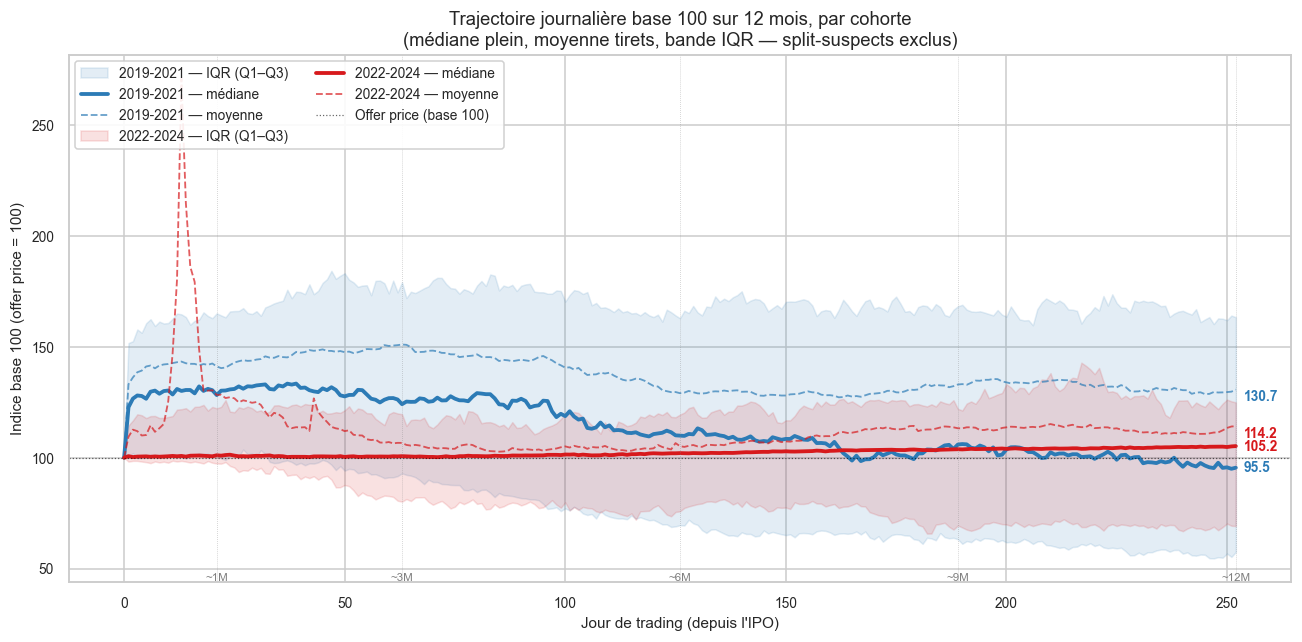

Enregistré : trajectoire_base100_12m_agregee.png


In [ ]:
# ── Graphique : trajectoire base 100 agrégée sur 12 mois ───────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for c in ['2019-2021', '2022-2024']:
    s = agg[agg['cohort'] == c].sort_values('trading_day')
    col = COLORS[c]

    # Bande IQR
    ax.fill_between(s['trading_day'], s['q25'], s['q75'],
                    alpha=0.13, color=col, label=f'{c} — IQR (Q1–Q3)')

    # Médiane (trait plein épais)
    ax.plot(s['trading_day'], s['median'], color=col, linewidth=2.5,
            label=f'{c} — médiane')

    # Moyenne (tirets fins)
    ax.plot(s['trading_day'], s['mean'], color=col, linewidth=1.2,
            linestyle='--', alpha=0.7, label=f'{c} — moyenne')

    # Annotation valeur finale
    last = s[s['trading_day'] == s['trading_day'].max()].iloc[0]
    for val, style, va in [(last['median'], 'solid', 'center'),
                            (last['mean'],   'dashed', 'top')]:
        ax.annotate(
            f"{val:.1f}",
            xy=(last['trading_day'], val),
            xytext=(5, 0), textcoords='offset points',
            fontsize=9, color=col, fontweight='bold', va=va
        )

ax.axhline(100, color='black', linewidth=0.8, linestyle=':', alpha=0.6, label='Offer price (base 100)')

# Repères temporels
for d, lbl in [(21, '~1M'), (63, '~3M'), (126, '~6M'), (189, '~9M'), (252, '~12M')]:
    ax.axvline(d, color='grey', linewidth=0.5, linestyle=':', alpha=0.5)
    ax.text(d, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 50,
            lbl, ha='center', fontsize=7.5, color='grey', va='bottom')

ax.set_xlabel('Jour de trading (depuis l\'IPO)')
ax.set_ylabel('Indice base 100 (offer price = 100)')
ax.set_title(
    'Trajectoire journalière base 100 sur 12 mois, par cohorte\n'
    '(médiane plein, moyenne tirets, bande IQR — split-suspects exclus)',
    fontsize=12
)
ax.legend(ncol=2, loc='upper left', framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

plt.tight_layout()
plt.savefig(IMG_DIR / 'trajectoire_base100_12m_agregee.png', dpi=150, bbox_inches='tight')
plt.show()
print('Enregistré : trajectoire_base100_12m_agregee.png')


## 2. Graphiques individuels par ticker

Chaque sous-graphique affiche l'indice `close / OfferPrice × 100` sur 252 jours pour un ticker.
La ligne horizontale en pointillés représente la base 100 (offer price).
Le titre de chaque sous-graphique indique le ticker, la cohorte, et le rendement final à 12 mois.


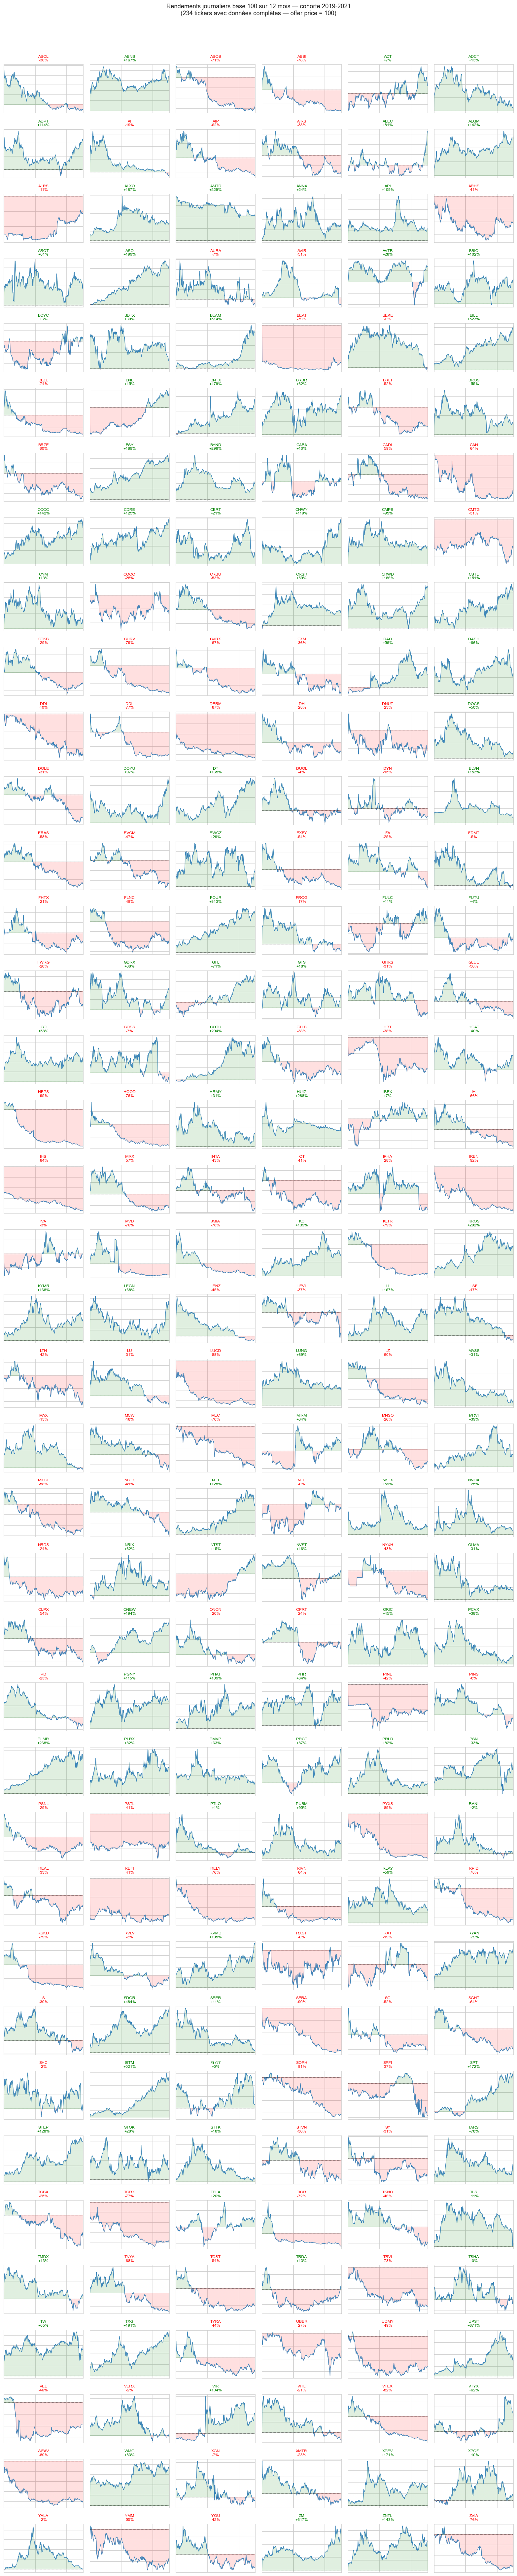

Enregistré : grille_tickers_2019_2021.png  (234 tickers)


In [ ]:
# ── Grille individuelle par ticker — une figure par cohorte ────────────────

def plot_grille_tickers(cohort_name, ncols=6):
    """Grille de sparklines base-100 pour tous les tickers d'une cohorte."""
    tickers_cohort = (
        tickers_ok[tickers_ok['cohort'] == cohort_name]['ticker']
        .sort_values()
        .unique()
    )

    # Garder seulement les tickers ayant des données sur 12 mois
    tickers_12m = (
        traj[
            (traj['cohort'] == cohort_name) &
            (traj['trading_day'] >= 252)
        ]['ticker'].unique()
    )
    tickers_cohort = [t for t in tickers_cohort if t in tickers_12m]

    n = len(tickers_cohort)
    nrows = int(np.ceil(n / ncols))
    col   = COLORS[cohort_name]

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 2.4, nrows * 1.8),
        squeeze=False
    )
    fig.suptitle(
        f'Rendements journaliers base 100 sur 12 mois — cohorte {cohort_name}\n'
        f'({n} tickers avec données complètes — offer price = 100)',
        fontsize=12, y=1.01
    )

    for idx, ticker in enumerate(tickers_cohort):
        ax = axes[idx // ncols][idx % ncols]
        serie = (
            traj[(traj['ticker'] == ticker) & (traj['cohort'] == cohort_name)]
            .sort_values('trading_day')
        )

        # Rendement final
        final_val = serie[serie['trading_day'] == serie['trading_day'].max()]['indice_100'].values
        ret_12m   = final_val[0] - 100 if len(final_val) else np.nan
        ret_color = 'green' if ret_12m >= 0 else 'red'

        ax.plot(serie['trading_day'], serie['indice_100'],
                color=col, linewidth=1.0, alpha=0.9)
        ax.axhline(100, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
        ax.fill_between(serie['trading_day'], serie['indice_100'], 100,
                         where=serie['indice_100'] >= 100, alpha=0.12,
                         color='green', interpolate=True)
        ax.fill_between(serie['trading_day'], serie['indice_100'], 100,
                         where=serie['indice_100'] < 100, alpha=0.12,
                         color='red', interpolate=True)

        ax.set_title(
            f'{ticker}\n{ret_12m:+.0f}%' if not np.isnan(ret_12m) else ticker,
            fontsize=8,
            color=ret_color
        )
        ax.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
        ax.set_xlim(0, 252)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    # Masquer les axes vides
    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    plt.tight_layout()
    fname = IMG_DIR / f'grille_tickers_{cohort_name.replace("-","_")}.png'
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Enregistré : {fname.name}  ({n} tickers)')


plot_grille_tickers('2019-2021')


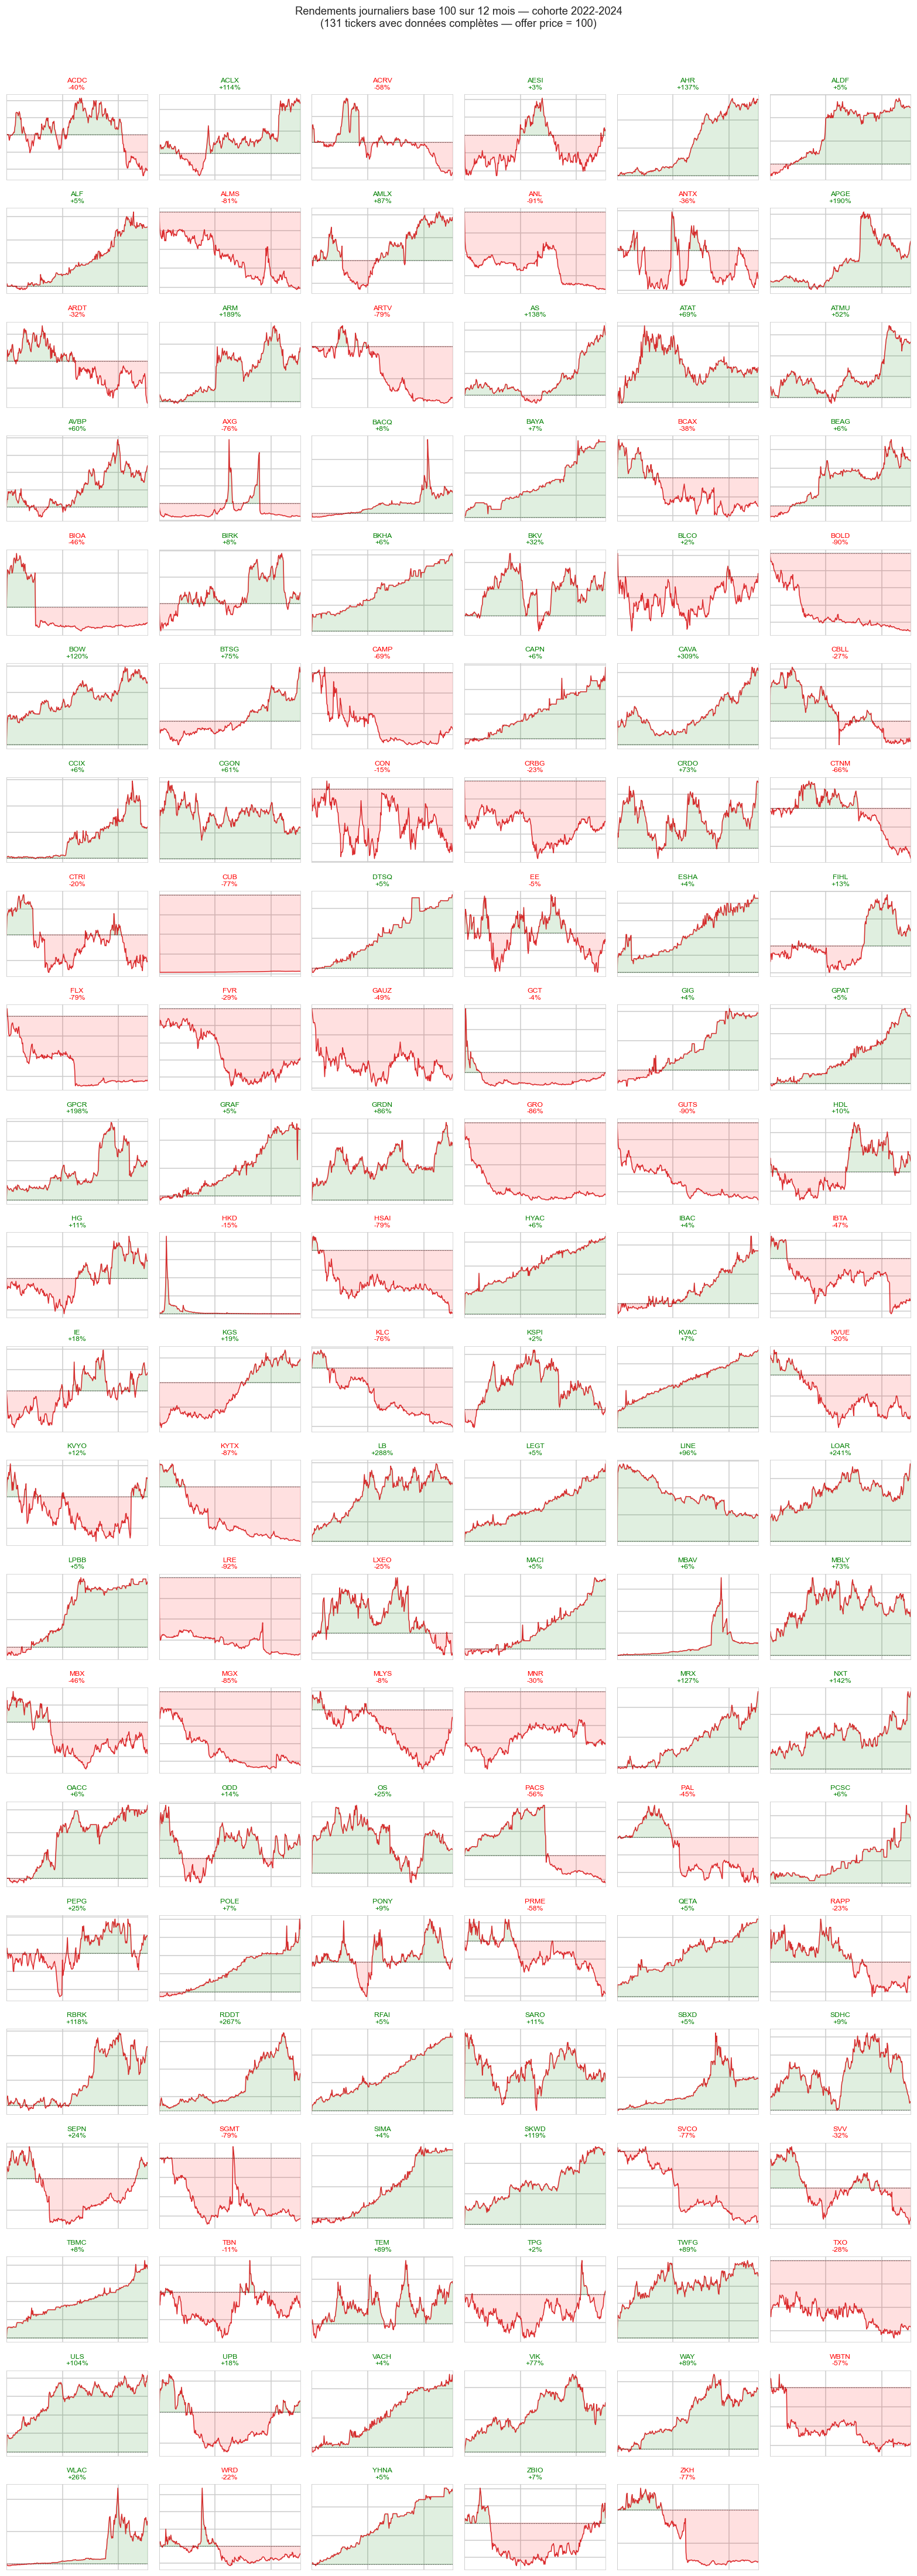

Enregistré : grille_tickers_2022_2024.png  (131 tickers)


In [ ]:
plot_grille_tickers('2022-2024')


## 3. Distribution des rendements journaliers par trimestre

Pour chaque ticker valide, on calcule le rendement journalier `r_t = close_t / close_{t-1} − 1`.
On regroupe ensuite par trimestre depuis l'IPO (T1 = jours 1–63, T2 = 64–126, T3 = 127–189, T4 = 190–252)
et on trace un violin-plot par cohorte.


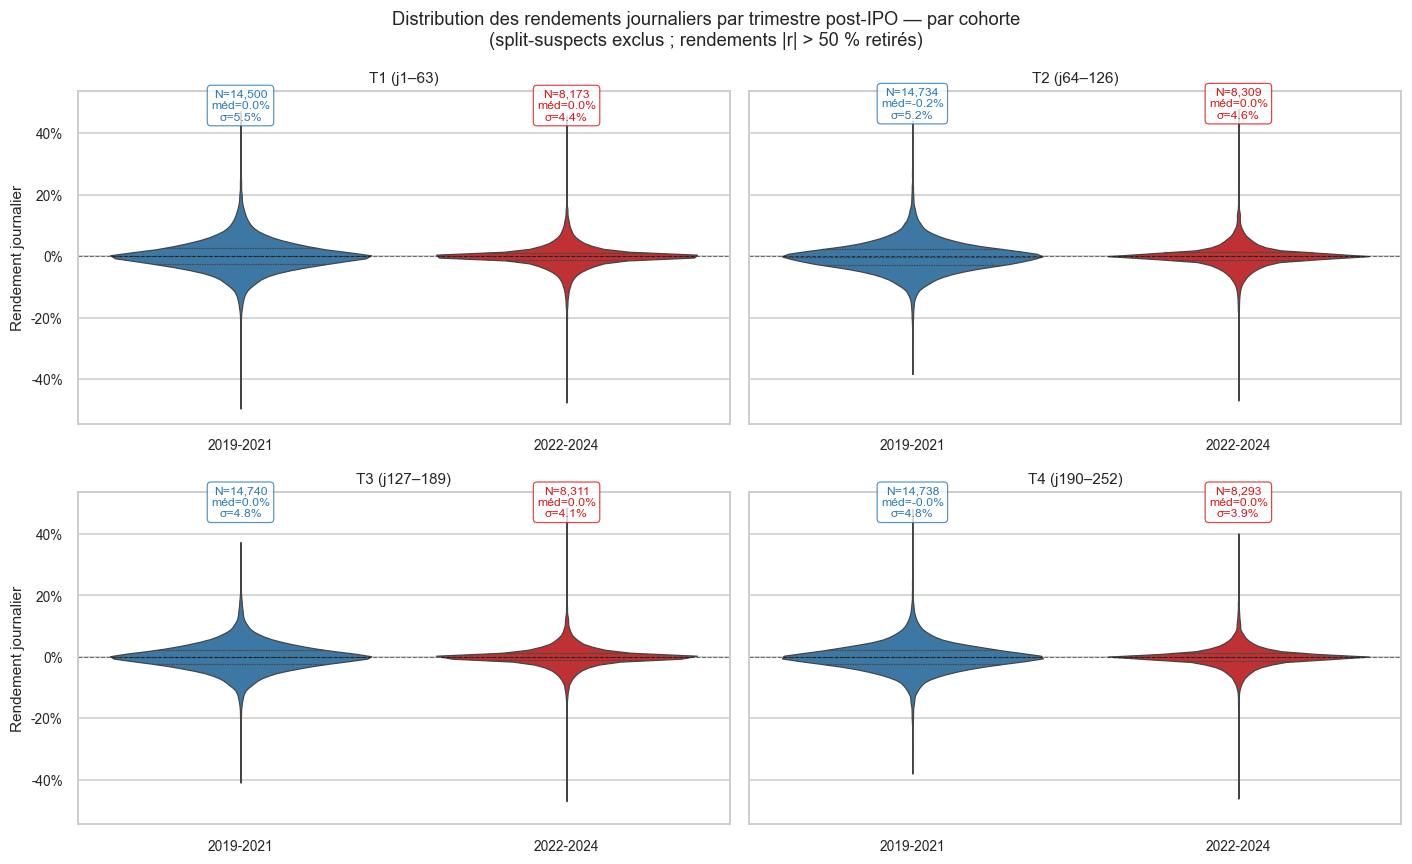

Enregistré : distribution_ret_journaliers_trimestriels.png


In [ ]:
# ── Distribution des rendements journaliers par trimestre ──────────────────

# Calcul du rendement journalier par ticker
traj_sorted = traj.sort_values(['ticker','cohort','trading_day'])
traj_sorted['ret_daily'] = (
    traj_sorted.groupby(['ticker','cohort'])['indice_100']
    .pct_change()
)

# Assigner un trimestre (depuis l'IPO)
bins   = [0, 63, 126, 189, 252]
labels = ['T1 (j1–63)', 'T2 (j64–126)', 'T3 (j127–189)', 'T4 (j190–252)']
traj_sorted['trimestre'] = pd.cut(
    traj_sorted['trading_day'], bins=bins, labels=labels, right=True
)

# Filtrer valeurs aberrantes (exclure les premiers jours, rendements > ±50 %)
daily_clean = traj_sorted[
    traj_sorted['trading_day'] >= 2
].copy()
daily_clean = daily_clean[
    daily_clean['ret_daily'].between(-0.50, 0.50)
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
axes = axes.flatten()

for i, trim in enumerate(labels):
    ax   = axes[i]
    data = daily_clean[daily_clean['trimestre'] == trim]

    sns.violinplot(
        data=data, x='cohort', y='ret_daily',
        order=['2019-2021','2022-2024'],
        palette=COLORS, ax=ax,
        inner='quartile', cut=0, linewidth=0.8
    )
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)

    for j, c in enumerate(['2019-2021','2022-2024']):
        sub = data[data['cohort'] == c]['ret_daily'].dropna()
        n   = len(sub)
        med = sub.median()
        vol = sub.std()
        ax.text(j, ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] != 0 else 0.35,
                f'N={n:,}\nméd={med*100:.1f}%\nσ={vol*100:.1f}%',
                ha='center', fontsize=8, color=COLORS[c],
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COLORS[c], alpha=0.8, lw=0.8))

    ax.set_title(trim, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Rendement journalier' if i % 2 == 0 else '')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

fig.suptitle(
    'Distribution des rendements journaliers par trimestre post-IPO — par cohorte\n'
    '(split-suspects exclus ; rendements |r| > 50 % retirés)',
    fontsize=12
)
plt.tight_layout()
plt.savefig(IMG_DIR / 'distribution_ret_journaliers_trimestriels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Enregistré : distribution_ret_journaliers_trimestriels.png')


## 4. Top 15 / Flop 15 tickers à 12 mois


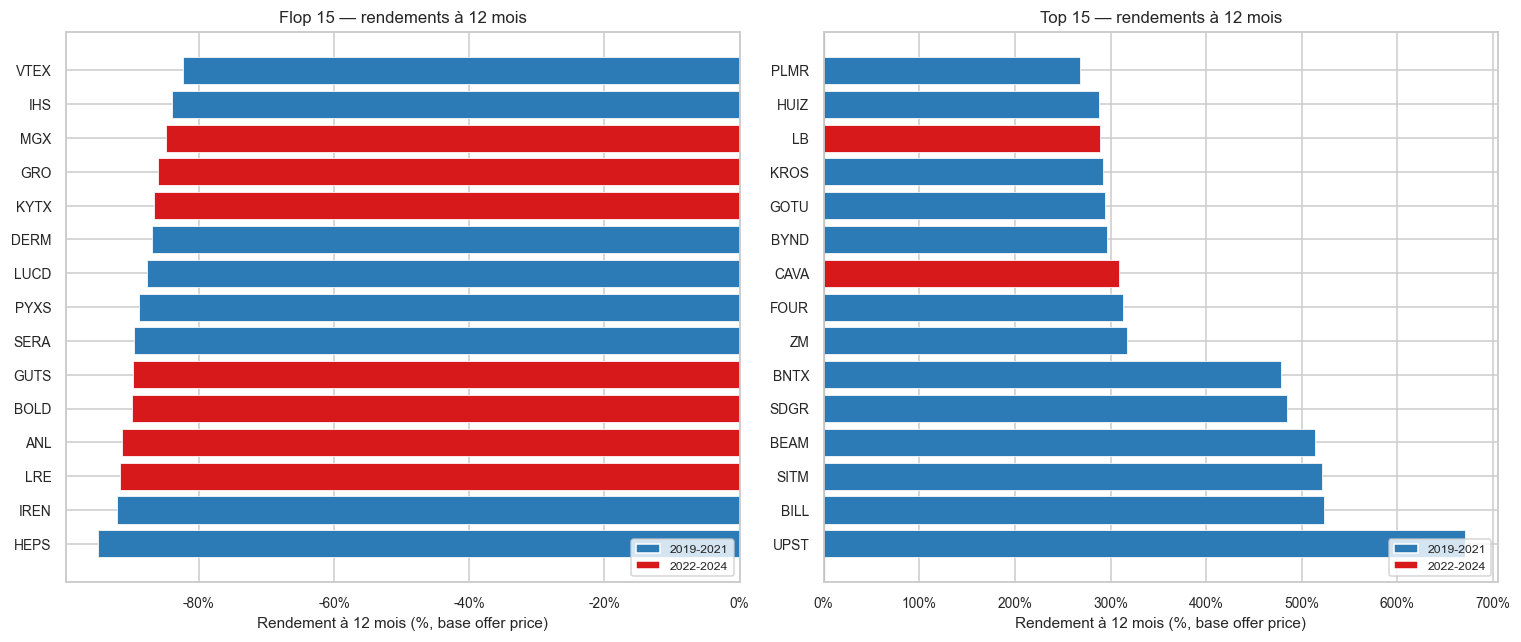

Enregistré : top_flop_15_tickers_12m.png


In [ ]:
# ── Top 15 / Flop 15 à 12 mois ─────────────────────────────────────────────

# Rendement final à 252 jours pour chaque ticker
ret_12m = (
    traj[traj['trading_day'] == 252][['ticker','cohort','indice_100']]
    .copy()
    .rename(columns={'indice_100': 'indice_252'})
)
ret_12m['return_12m_pct'] = ret_12m['indice_252'] - 100
ret_12m = ret_12m.sort_values('return_12m_pct')

flop15 = ret_12m.head(15).copy()
top15  = ret_12m.tail(15).sort_values('return_12m_pct', ascending=False).copy()

fig, (ax_flop, ax_top) = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_sub, title in [
    (ax_flop, flop15, 'Flop 15 — rendements à 12 mois'),
    (ax_top,  top15,  'Top 15 — rendements à 12 mois')
]:
    colors_bar = [COLORS[c] for c in df_sub['cohort']]
    bars = ax.barh(
        df_sub['ticker'], df_sub['return_12m_pct'],
        color=colors_bar, edgecolor='white', linewidth=0.5
    )
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_xlabel('Rendement à 12 mois (%, base offer price)')
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

    # Légende cohorte
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=COLORS[c], label=c) for c in ['2019-2021','2022-2024']]
    ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(IMG_DIR / 'top_flop_15_tickers_12m.png', dpi=150, bbox_inches='tight')
plt.show()
print('Enregistré : top_flop_15_tickers_12m.png')


## 5. Volatilité réalisée annualisée par cohorte

La volatilité réalisée pour chaque ticker est l'écart-type des rendements journaliers sur les 252 jours, annualisé par `σ_annuel = σ_jour × √252`.


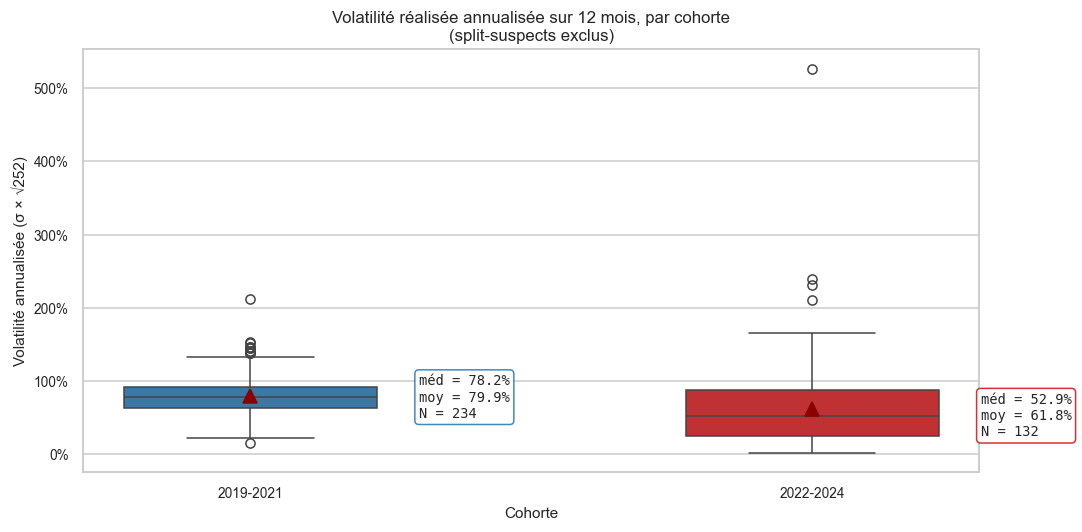

Enregistré : volatilite_annualisee_12m.png

=== Statistiques volatilité réalisée annualisée par cohorte ===


AttributeError: 'DataFrame' object has no attribute 'applymap'

In [ ]:
# ── Volatilité réalisée annualisée ─────────────────────────────────────────

vol_df = (
    traj_sorted[traj_sorted['trading_day'].between(2, 252)]
    .groupby(['ticker','cohort'])['ret_daily']
    .std()
    .reset_index()
    .rename(columns={'ret_daily': 'vol_daily'})
)
vol_df['vol_annualisee'] = vol_df['vol_daily'] * np.sqrt(252)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=vol_df, x='cohort', y='vol_annualisee',
    order=['2019-2021','2022-2024'],
    palette=COLORS, ax=ax, width=0.45
)

for i, c in enumerate(['2019-2021','2022-2024']):
    sub = vol_df[vol_df['cohort'] == c]['vol_annualisee'].dropna()
    med = sub.median()
    moy = sub.mean()
    ax.plot(i, moy, marker='^', color='darkred', markersize=9, zorder=5)
    ax.text(i + 0.3, med,
            f'méd = {med*100:.1f}%\nmoy = {moy*100:.1f}%\nN = {len(sub)}',
            fontsize=9, va='center', ha='left', family='monospace',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COLORS[c], lw=1, alpha=0.9))

ax.set_ylabel('Volatilité annualisée (σ × √252)')
ax.set_xlabel('Cohorte')
ax.set_title('Volatilité réalisée annualisée sur 12 mois, par cohorte\n(split-suspects exclus)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

plt.tight_layout()
plt.savefig(IMG_DIR / 'volatilite_annualisee_12m.png', dpi=150, bbox_inches='tight')
plt.show()
print('Enregistré : volatilite_annualisee_12m.png')

print('\n=== Statistiques volatilité réalisée annualisée par cohorte ===')
print(
    vol_df.groupby('cohort')['vol_annualisee']
          .describe(percentiles=[.25,.5,.75])
          .applymap(lambda x: f'{x*100:.1f}%' if isinstance(x, float) else x)
)
